## Day 2 - Data Cleaning & Feature Engineering

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df1 = pd.read_excel(
    '../data/online_retail_II.xlsx',
    sheet_name='Year 2009-2010'
)

df2 = pd.read_excel(
    '../data/online_retail_II.xlsx',
    sheet_name='Year 2010-2011'
)

df = pd.concat([df1, df2], ignore_index=True)

##  Remove Cancellations

In [3]:
# Invoices starting with 'C' are cancellations — remove them
print(f"Rows before: {len(df)}")
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"Rows after removing cancellations: {len(df)}")

Rows before: 1067371
Rows after removing cancellations: 1047877


## Remove Invalid Rows

In [4]:
# Remove rows where Quantity <= 0 (returns, errors)
df = df[df['Quantity'] > 0]

# Remove rows where Price <= 0 (free/test items)
df = df[df['Price'] > 0]

# Remove rows with missing Customer ID (we can't do customer analysis without it)
df = df.dropna(subset=['Customer ID'])

print(f"Clean dataset rows: {len(df)}")

Clean dataset rows: 805549


## Fix Data Types

In [5]:
# Customer ID should be string, not float
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)

# InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df.dtypes)

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID            object
Country                object
dtype: object


## Add New Columns

In [6]:
# Revenue per line item
df['TotalRevenue'] = df['Quantity'] * df['Price']

# Extract date parts (useful later)
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek   # 0=Monday, 6=Sunday
df['Hour'] = df['InvoiceDate'].dt.hour
df['Date'] = df['InvoiceDate'].dt.date

## RFM Feature Engineering

In [7]:
# Set reference date = 1 day after last invoice date
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),   # count unique invoices
    Monetary  = ('TotalRevenue','sum')
).reset_index()

print(rfm.head())
print(rfm.describe())

  Customer ID  Recency  Frequency  Monetary
0       12346      326         12  77556.46
1       12347        2          8   5633.32
2       12348       75          5   2019.40
3       12349       19          4   4428.69
4       12350      310          1    334.40
           Recency    Frequency       Monetary
count  5878.000000  5878.000000    5878.000000
mean    201.331916     6.289384    3018.616737
std     209.338707    13.009406   14737.731040
min       1.000000     1.000000       2.950000
25%      26.000000     1.000000     348.762500
50%      96.000000     3.000000     898.915000
75%     380.000000     7.000000    2307.090000
max     739.000000   398.000000  608821.650000


## Rolling Average Features

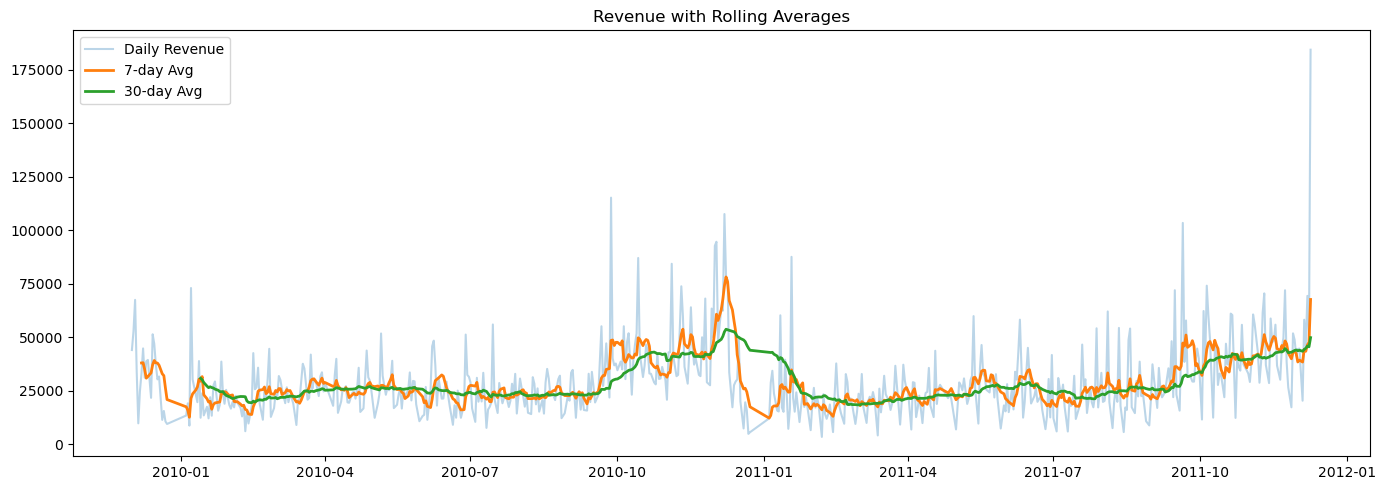

In [8]:
# Daily revenue
daily_revenue = df.groupby('Date')['TotalRevenue'].sum().reset_index()
daily_revenue = daily_revenue.sort_values('Date')
daily_revenue['Date'] = pd.to_datetime(daily_revenue['Date'])

# 7-day rolling average (smooths weekly noise)
daily_revenue['Revenue_7day_avg'] = daily_revenue['TotalRevenue'].rolling(window=7).mean()

# 30-day rolling average (shows monthly trend)
daily_revenue['Revenue_30day_avg'] = daily_revenue['TotalRevenue'].rolling(window=30).mean()

plt.figure(figsize=(14,5))
plt.plot(daily_revenue['Date'], daily_revenue['TotalRevenue'], alpha=0.3, label='Daily Revenue')
plt.plot(daily_revenue['Date'], daily_revenue['Revenue_7day_avg'], label='7-day Avg', linewidth=2)
plt.plot(daily_revenue['Date'], daily_revenue['Revenue_30day_avg'], label='30-day Avg', linewidth=2)
plt.legend()
plt.title('Revenue with Rolling Averages')
plt.tight_layout()
plt.savefig('Day2_rolling_avg.png')
plt.show()

## Lag Features

In [9]:
# Lag-1: yesterday's revenue
daily_revenue['Revenue_lag1'] = daily_revenue['TotalRevenue'].shift(1)

# Lag-7: revenue from same day last week
daily_revenue['Revenue_lag7'] = daily_revenue['TotalRevenue'].shift(7)

# Lag-30: revenue from same day last month
daily_revenue['Revenue_lag30'] = daily_revenue['TotalRevenue'].shift(30)

# Drop rows where lags create NaN (first 30 rows)
daily_revenue = daily_revenue.dropna()
print(daily_revenue.head())

         Date  TotalRevenue  Revenue_7day_avg  Revenue_30day_avg  \
30 2010-01-14     23843.470      31634.720000       30179.196000   
31 2010-01-15     13507.540      23130.764286       28864.714333   
32 2010-01-17     17548.290      21306.548571       27200.354667   
33 2010-01-18     12132.690      19718.635714       26469.297333   
34 2010-01-19     22011.471      20050.940143       26876.244700   

    Revenue_lag1  Revenue_lag7  Revenue_lag30  
30      12409.99       8740.69       44048.69  
31      23843.47      73035.23       52941.99  
32      13507.54      30317.80       67479.08  
33      17548.29      23248.08       34064.41  
34      12132.69      19685.34        9803.05  


## Data Validation

In [10]:
# Final check — no nulls in important columns
print(df.isnull().sum())

# Sanity check: all revenue positive
print(f"Negative revenue rows: {(df['TotalRevenue'] < 0).sum()}")

# Save clean data
# df.to_csv('RetailPulse/notebooks/data/clean_retail.csv', index=False)
# daily_revenue.to_csv('RetailPulse/notebooks/data/daily_revenue_features.csv', index=False)
# print("Data saved!")

import os

os.makedirs('../data', exist_ok=True)

df.to_csv('../data/clean_retail.csv', index=False)
daily_revenue.to_csv('../data/daily_revenue_features.csv', index=False)

print("Data saved!")

Invoice         0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
Price           0
Customer ID     0
Country         0
TotalRevenue    0
Year            0
Month           0
DayOfWeek       0
Hour            0
Date            0
dtype: int64
Negative revenue rows: 0
Data saved!


In [11]:
daily_revenue.to_csv('../data/daily_revenue_full.csv', index=False)